# Diplomski rad - Primena transformer arhitekture neuronskih mreza za detekciju DoS napada

## Beleznica 3: Balansiranje klasa i bazni model

Cilj ove beleznice je resavanje uocene neizbalansiranosti klasa primenom class weights tehnike, kao i implementacija i evaluacija baznog (baseline) modela - Random Forest klasifikatora - cija ce tacnost sluziti kao referentna vrednost za poredjenje sa transformer modelom u narednoj beleznici.

### 1. Ucitavanje pripremljenih podataka

Ucitavaju se skupovi podataka pripremljeni u prethodnoj beleznici (skalirani feature-i i numericke labele), kao i pomocni objekti: mapiranje klasa i spisak naziva atributa.



In [ ]:
from pathlib import Path
import numpy as np
import joblib

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / "X_train.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

label_mapping = joblib.load(DATA_DIR / "label_mapping.pkl")
feature_cols = joblib.load(DATA_DIR / "feature_cols.pkl")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Broj klasa:", len(label_mapping))
print("Mapiranje klasa:", label_mapping)

Mounted at /content/drive
X_train shape: (467984, 67)
X_test shape: (116996, 67)
Broj klasa: 5
Mapiranje klasa: {'Benign': np.int64(0), 'DoS GoldenEye': np.int64(1), 'DoS Hulk': np.int64(2), 'DoS Slowhttptest': np.int64(3), 'DoS slowloris': np.int64(4)}


### 2. Izracunavanje tezina klasa (class weights)

S obzirom na znacajnu neizbalansiranost klasa (odnos najbrojnije i najredje klase priblizno 75:1), primenjuje se tehnika class weights, kojom se svakoj klasi dodeljuje tezinski koeficijent obrnuto proporcionalan njenoj zastupljenosti u skupu za treniranje. Na ovaj nacin, greske modela na retko zastupljenim klasama se tokom treniranja kaznjavaju vise nego greske na dominantnim klasama, cime se sprecava da model favorizuje vecinsku klasu.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

inverse_label_mapping = {v: k for k, v in label_mapping.items()}

print("Tezine klasa:")
for cls, w in class_weights.items():
    print(f"  {cls} ({inverse_label_mapping[cls]}): {w:.3f}")

Tezine klasa:
  0 (Benign): 0.299
  1 (DoS GoldenEye): 11.374
  2 (DoS Hulk): 0.677
  3 (DoS Slowhttptest): 22.381
  4 (DoS slowloris): 21.726


### 3. Treniranje baznog modela (Random Forest)

Kao bazni (baseline) model koristi se Random Forest klasifikator, ciji rezultati sluze kao referentna vrednost za poredjenje sa transformer arhitekturom u narednoj beleznici. Izracunate tezine klasa prosledjuju se modelu radi ublazavanja efekata neizbalansiranosti podataka.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_model.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Model istreniran za {elapsed:.1f} sekundi.")

Model istreniran za 159.8 sekundi.


### 4. Evaluacija baznog modela

Kvalitet modela ocenjuje se na skupu za testiranje, koriscenjem standardnih metrika za multi-class klasifikaciju: preciznost (precision), odziv (recall) i F1-mera, izracunatih za svaku klasu pojedinacno, s obzirom na to da ukupna tacnost (accuracy) moze biti obmanjujuca metrika kod neizbalansiranih skupova podataka.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_rf = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_rf)
print(f"Ukupna tacnost (accuracy): {acc:.4f}")
print()

target_names = [inverse_label_mapping[i] for i in classes]
print(classification_report(y_test, y_pred_rf, target_names=target_names))

Ukupna tacnost (accuracy): 0.9987

                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00     78247
   DoS GoldenEye       1.00      0.99      1.00      2057
        DoS Hulk       1.00      1.00      1.00     34569
DoS Slowhttptest       0.98      1.00      0.99      1046
   DoS slowloris       1.00      0.99      0.99      1077

        accuracy                           1.00    116996
       macro avg       0.99      1.00      0.99    116996
    weighted avg       1.00      1.00      1.00    116996



Bazni model postize ukupnu tacnost od 99.87% na testnom skupu, sa F1-merom od najmanje 0.99 za svaku pojedinacnu klasu, ukljucujuci i najredje zastupljene klase (DoS Slowhttptest i DoS slowloris). Rezultati pokazuju da Random Forest model uz primenu class weights tehnike ostvaruje visoke i ujednacene performanse i na manjinskim klasama, uprkos uocenoj neizbalansiranosti podataka.

Dobijeni rezultat ukazuje na visoku diskriminativnu moc koriscenih flow-based atributa na posmatranom skupu podataka, sto omogucava Random Forest modelu da veoma uspesno razlikuje benigni saobracaj i razlicite podtipove DoS napada. Ovaj rezultat predstavlja referentnu vrednost za evaluaciju transformer arhitekture u narednim beleznicama.

### 5. Matrica konfuzije

Matrica konfuzije prikazuje detaljnu raspodelu predikcija modela po klasama, omogucavajuci uvid u to sa kojim klasama model najcesce mesa odredjeni tip saobracaja. Dijagonalni elementi predstavljaju tacno klasifikovane instance, dok elementi van dijagonale ukazuju na pogresno klasifikovane instance i njihovu stvarnu, odnosno predvidjenu klasu.

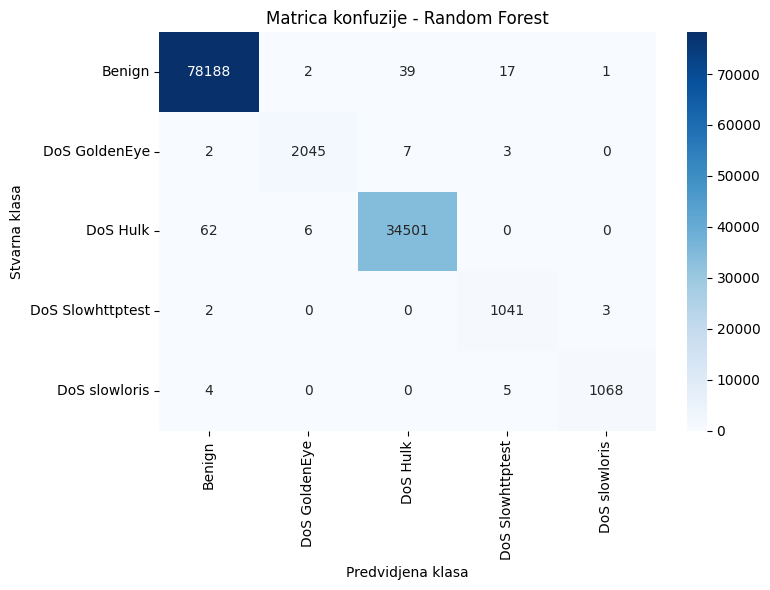

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predvidjena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije - Random Forest')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "rf_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

Matrica konfuzije potvrdjuje visoku tacnost modela po svim klasama. Posmatrano u apsolutnim vrednostima, najveci broj gresaka javlja se izmedju klasa Benign i DoS Hulk (39 i 62 pogresno klasifikovane instance, redom), sto je ocekivano s obzirom na to da su ove dve klase najbrojnije u skupu podataka, pa i mali procenat greske rezultuje vecim apsolutnim brojem.

Posmatrano relativno, u odnosu na velicinu svake klase, najveci udeo gresaka javlja se izmedju klasa DoS Slowhttptest i DoS slowloris (0,29% i 0,46% pogresno klasifikovanih instanci unutar svoje klase, redom), pri cemu se greske izmedju ove dve klase gotovo iskljucivo javljaju medjusobno, a ne sa preostalim klasama. Ovakav rezultat pokazuje da je Random Forest model greske kod ove dve klase najcesce pravio njihovom medjusobnom zamenom.

### 6. Vaznost atributa (Feature Importance)

Random Forest model omogucava izracunavanje relativne vaznosti svakog atributa na osnovu ukupnog smanjenja necistoce (impurity) koje se ostvaruje podelama zasnovanim na tom atributu kroz stabla u ansamblu. Ovaj uvid koristi se kasnije u radu za poredjenje sa obrascima paznje (attention) transformer modela.

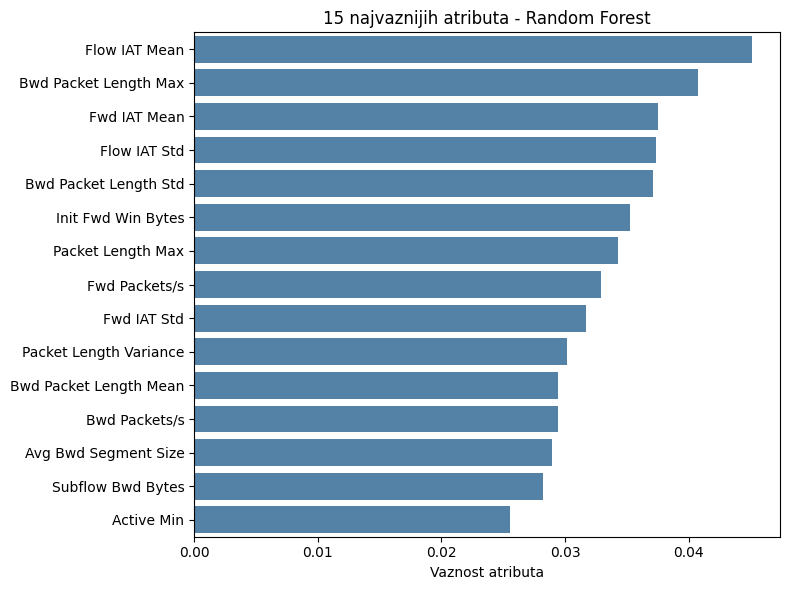

In [ ]:
import pandas as pd

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Atribut': feature_cols,
    'Vaznost': importances
}).sort_values('Vaznost', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df, x='Vaznost', y='Atribut', color='steelblue')
plt.title('15 najvaznijih atributa - Random Forest')
plt.xlabel('Vaznost atributa')
plt.ylabel('')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "rf_feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

Analiza vaznosti atributa pokazuje da znacajan doprinos klasifikaciji daju atributi vezani za vremenske razmake izmedju uzastopnih paketa (Flow IAT Mean, Fwd IAT Mean, Flow IAT Std), kao i atributi koji opisuju velicinu paketa (Bwd Packet Length Max i Bwd Packet Length Std). Dobijeni rezultati ukazuju na to da su vremenske i velicinske karakteristike mreznog saobracaja imale znacajan uticaj na odluke Random Forest modela.

Ovi rezultati predstavljaju dodatnu osnovu za kasniju analizu transformer modela. U narednim beleznicama analiziraju se i attention tezine transformer arhitekture kako bi se ispitalo kojim atributima model pridaje vecu paznju tokom klasifikacije.

### 7. Cuvanje rezultata baznog modela

Rezultati baznog modela (tacnost, vreme treniranja i predikcije) cuvaju se radi kasnijeg poredjenja sa rezultatima transformer modela.

In [ ]:
import joblib

rf_results = {
    'accuracy': acc,
    'training_time_sec': elapsed,
    'y_pred': y_pred_rf
}

joblib.dump(
    rf_results,
    DATA_DIR / "rf_baseline_results.pkl"
)

print("Rezultati baznog modela sacuvani.")

Rezultati baznog modela sacuvani.


## Zakljucak beleznice

Random Forest model sa primenjenim class weights postigao je tacnost od 99.87% na testnom skupu, uz visoke i ujednacene F1-mere po svim klasama, ukljucujuci i manjinske klase. Analiza matrice konfuzije pokazala je mali broj pogresnih klasifikacija, dok je analiza vaznosti atributa ukazala na znacajan doprinos atributa vezanih za vremenske razmake izmedju paketa i njihove velicine. Na ovaj nacin uspostavljena je referentna vrednost za kasnije poredjenje sa transformer arhitekturom.

**Sledeci korak:** Beleznica `04_transformer_model.ipynb`, u okviru koje se definise, trenira i evaluira transformer arhitektura za klasifikaciju DoS napada.